In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q codecarbon thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.3 MB/s eta 0:00:00


In [37]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets
from torchvision.models import (
    shufflenet_v2_x1_0,
    ShuffleNet_V2_X1_0_Weights
)

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from thop import profile
from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

In [38]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 160
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

SEEDS = [42, 123, 777]

# FP32 precision declaration
torch.set_default_dtype(torch.float32)

# Batch Scheduling Declaration
BATCH_SCHEDULING = "Constant Batch Size (No Scheduling)"

print("========== GLOBAL CONFIGURATION ==========")
print(f"Device              : {DEVICE}")
print(f"Input Resolution    : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Epochs              : {EPOCHS}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Precision           : FP32")
print(f"Batch Scheduling    : {BATCH_SCHEDULING}")

========== GLOBAL CONFIGURATION ==========
Device              : cuda
Input Resolution    : 160x160
Batch Size          : 64
Epochs              : 10
Learning Rate       : 0.001
Precision           : FP32
Batch Scheduling    : Constant Batch Size (No Scheduling)


In [55]:
print("\n========== HARDWARE SPECIFICATION ==========")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version   : {torch.version.cuda}")
else:
    print("Running on CPU")


========== HARDWARE SPECIFICATION ==========
Device : cuda
GPU            : Tesla T4
CUDA Version   : 12.8


In [39]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [40]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset_path = "/content/drive/MyDrive/EuroSAT_RGB/EuroSAT"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("\n========== DATASET INFO ==========")
print("Total Images :", len(dataset))
print("Classes      :", dataset.classes)


========== DATASET INFO ==========
Total Images : 27000
Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [41]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("\n========== DATA SPLIT PROTOCOL ==========")
print("Train Size      :", len(train_dataset))
print("Validation Size :", len(val_dataset))
print("Test Size       :", len(test_dataset))


========== DATA SPLIT PROTOCOL ==========
Train Size      : 21600
Validation Size : 2700
Test Size       : 2700


In [42]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [43]:
# ==========================================================
# PRETRAINED WEIGHTS JUSTIFICATION
# ==========================================================
# ShuffleNetV2 pretrained ImageNet weights are used
# to improve transfer learning performance,
# convergence speed, and feature extraction capability
# on the EuroSAT dataset.

In [44]:
def get_shufflenet():
    weights = ShuffleNet_V2_X1_0_Weights.DEFAULT
    model = shufflenet_v2_x1_0(weights=weights)

    # FREEZE FEATURE EXTRACTOR
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE CLASSIFIER
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, len(dataset.classes))

    return model.to(DEVICE)

In [45]:
def calculate_flops():
    model = get_shufflenet()
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    flops, params = profile(
        model,
        inputs=(dummy_input,),
        verbose=False
    )

    global gflops
    gflops = flops / 1e9

    print("\n========== MODEL COMPLEXITY ==========")
    print(f"FLOPs      : {gflops:.3f} GFLOPs")
    print(f"Parameters : {params/1e6:.3f} Million")

calculate_flops()


========== MODEL COMPLEXITY ==========
FLOPs      : 0.077 GFLOPs
Parameters : 1.264 Million


In [47]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy

In [56]:
def train_and_evaluate_shufflenet(seed):
    # Set unique seed control for this run
    set_seed(seed)

    # Initialize Model, Criterion, and Optimizer
    model = get_shufflenet()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    start_time = time.time()

    # Training Loop progression across epochs
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = (correct_train / total_train) * 100

        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = (correct_val / total_val) * 100

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    runtime = time.time() - start_time

    # Test Split Final Evaluation Protocol
    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true_list.extend(labels.numpy())
            y_pred_list.extend(predicted.cpu().numpy())

    # Calculate Final Stable Test Metrics
    acc = accuracy_score(y_true_list, y_pred_list)
    prec = precision_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    rec = recall_score(y_true_list, y_pred_list, average='macro', zero_division=0)
    f1 = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)

    return acc, prec, rec, f1, runtime, train_losses, val_losses, train_accs, val_accs, y_true_list, y_pred_list


Running Seed: 42
Epoch [1/10] -> Train Loss: 1.7871 | Val Loss: 1.4031 | Val Acc: 80.48%
Epoch [2/10] -> Train Loss: 1.1902 | Val Loss: 1.0113 | Val Acc: 83.52%
Epoch [3/10] -> Train Loss: 0.9048 | Val Loss: 0.8229 | Val Acc: 84.63%
Epoch [4/10] -> Train Loss: 0.7532 | Val Loss: 0.7022 | Val Acc: 84.96%
Epoch [5/10] -> Train Loss: 0.6591 | Val Loss: 0.6241 | Val Acc: 85.78%
Epoch [6/10] -> Train Loss: 0.5856 | Val Loss: 0.5488 | Val Acc: 87.37%
Epoch [7/10] -> Train Loss: 0.5362 | Val Loss: 0.5040 | Val Acc: 87.52%
Epoch [8/10] -> Train Loss: 0.5010 | Val Loss: 0.4791 | Val Acc: 87.52%
Epoch [9/10] -> Train Loss: 0.4729 | Val Loss: 0.4450 | Val Acc: 89.07%
Epoch [10/10] -> Train Loss: 0.4470 | Val Loss: 0.4197 | Val Acc: 88.48%

Running Seed: 123
Epoch [1/10] -> Train Loss: 1.7866 | Val Loss: 1.4098 | Val Acc: 80.81%
Epoch [2/10] -> Train Loss: 1.1857 | Val Loss: 1.0259 | Val Acc: 81.52%
Epoch [3/10] -> Train Loss: 0.9070 | Val Loss: 0.8241 | Val Acc: 84.70%
Epoch [4/10] -> Train Loss

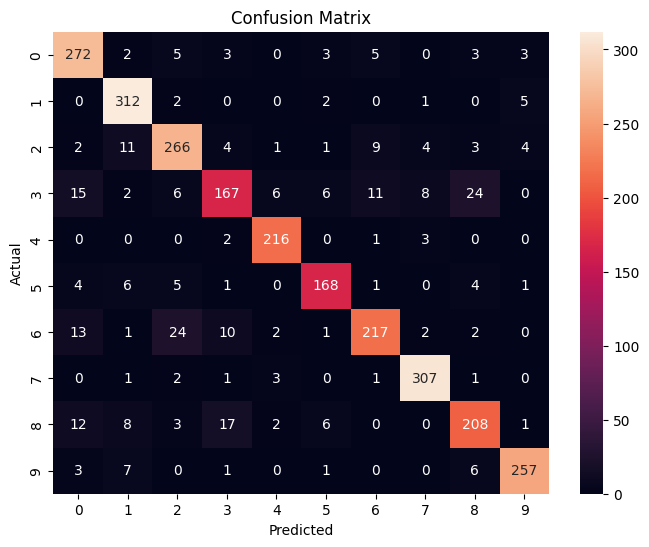

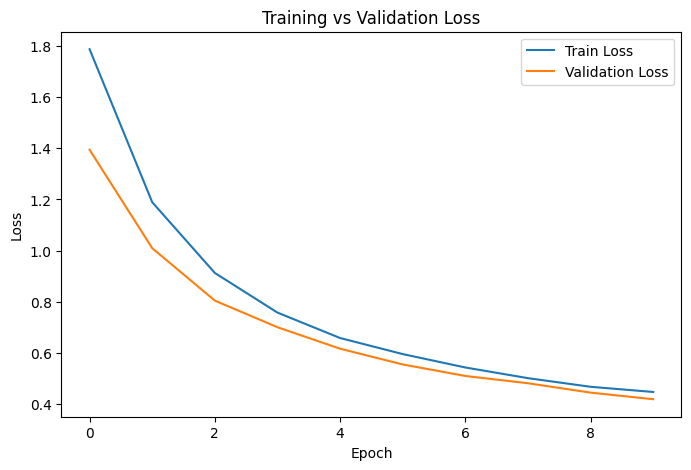

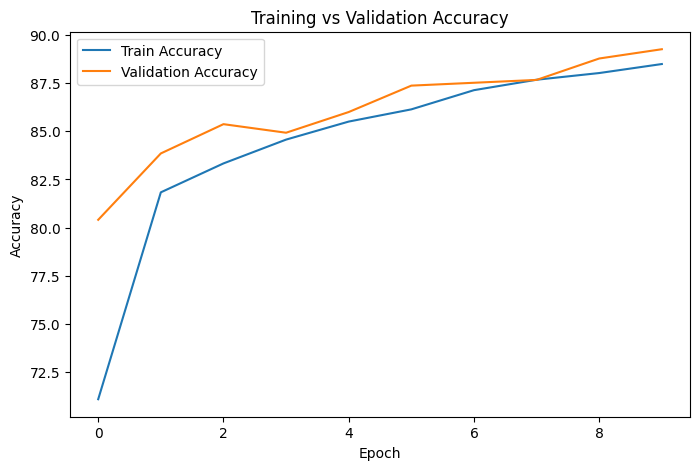


========== FINAL RESULTS ==========

Accuracy  : 0.8825 ± 0.0019
Precision : 0.8823 ± 0.0016
Recall    : 0.8774 ± 0.0027
F1 Score  : 0.8785 ± 0.0021
Runtime   : 2316.20 ± 1856.05 sec
CO2       : 0.032030 kg CO2eq


In [57]:
# ==========================================================
# MULTI-SEED EVALUATION + CO2 TRACKING
# ==========================================================
import os
os.makedirs("./codecarbon", exist_ok=True)

results = []

tracker = EmissionsTracker(
    project_name="ShuffleNet_GreenAI",
    tracking_mode="process",
    output_dir="./codecarbon",
    measure_power_secs=1,
    log_level="error"
)

tracker.start()

# Dictionaries to save trajectory for plotting later
final_plots_data = {}

for seed in SEEDS:
    print(f"\n==========================================")
    print(f"Running Seed: {seed}")
    print(f"==========================================")

    (
        acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    ) = train_and_evaluate_shufflenet(seed)

    results.append([
        float(acc),
        float(prec),
        float(rec),
        float(f1),
        float(runtime)
    ])

    # Storing last metrics series safely for visualization curves
    final_plots_data['train_loss'] = train_losses
    final_plots_data['val_loss'] = val_losses
    final_plots_data['train_acc'] = train_accs
    final_plots_data['val_acc'] = val_accs

# ==========================================================
# CO2 EMISSION
# ==========================================================
co2 = tracker.stop()

if co2 is None:
    co2 = 0.0

print("\n==============================")
print(f"CO2 Emission : {co2:.6f} kg CO2eq")
print("==============================")

results = np.array(results)

# ==========================================================
# CO2 EMISSION
# ==========================================================

co2 = tracker.stop()

if co2 is None:
    co2 = 0.0

print("\n==============================")
print(f"CO2 Emission : {co2:.6f} kg CO2eq")
print("==============================")

if len(results) == 0:
    raise ValueError("No successful runs completed.")

results = np.array(results)


# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)


# ==========================================================
# CONFUSION MATRIX
# ==========================================================

print("\n========== CONFUSION MATRIX ==========\n")

import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



# ==========================================================
# LOSS CURVE
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()



# ==========================================================
# ACCURACY CURVE
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()





# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n========== FINAL RESULTS ==========\n")

print(
    f"Accuracy  : {results[:,0].mean():.4f} ± {results[:,0].std():.4f}"
)

print(
    f"Precision : {results[:,1].mean():.4f} ± {results[:,1].std():.4f}"
)

print(
    f"Recall    : {results[:,2].mean():.4f} ± {results[:,2].std():.4f}"
)

print(
    f"F1 Score  : {results[:,3].mean():.4f} ± {results[:,3].std():.4f}"
)

print(
    f"Runtime   : {results[:,4].mean():.2f} ± {results[:,4].std():.2f} sec"
)

print(
    f"CO2       : {co2:.6f} kg CO2eq"
)


